# EJERCICIOS

## ACOMPLAMIENTO ENTRE CÚBITS

In [11]:
import numpy as np
from scipy.linalg import expm

# Matrices de Pauli
sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
I = np.eye(2)

# Parámetros
Ec = 1.0
Ej = 0.8

# Hamiltoniano qubit individual (modelo simplificado)
H_charge1 = Ec * sigma_z - Ej * sigma_x
H_charge2 = Ec * sigma_z - Ej * sigma_x

# Hamiltoniano acoplado
H_coupled = (
    np.kron(H_charge1, I) +
    np.kron(I, H_charge2) +
    0.05 * np.kron(sigma_x, sigma_x)
)

In [12]:
# Estado inicial |00>
psi0 = np.array([1, 0, 0, 0], dtype=complex)

In [13]:
def concurrence(psi):
    # Matriz densidad
    rho = np.outer(psi, np.conjugate(psi))
    
    # Matriz Y tensor Y
    sigma_y = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sigma_y, sigma_y)
    
    rho_tilde = Y @ np.conjugate(rho) @ Y
    
    # Autovalores
    eigvals = np.linalg.eigvals(rho @ rho_tilde)
    eigvals = np.sort(np.sqrt(np.abs(eigvals)))[::-1]
    
    return max(0, eigvals[0] - eigvals[1] - eigvals[2] - eigvals[3])

for t in np.linspace(0,5,20):
    U = expm(-1j * H_coupled * t)
    psi_t = U @ psi0
    print(concurrence(psi_t))

0
0.003272980178293065
0.04345725155352898
0.05079921552989532
0.04950832074207986
0.04889572085876196
0.05032045580379251
0.044061408252877236
0.026091656517650545
0.0013018361085158578
0.02527736218995976
0.04440864450537362
0.05276115434176267
0.05173952854688163
0.049911085123346036
0.05126270183300424
0.04644096262238867
0.029196662824820006
0.005053674093789091
0.025554918205952806


## ACOMPLAMIENTO ENTRE CÚBITS

In [14]:
from qutip import *
import numpy as np

# Operadores
sx = sigmax()
sz = sigmaz()
sm = sigmam()

# Hamiltoniano (simple)
H = 0.5 * sx

# Estado inicial |0>
psi0 = basis(2, 0)

# Tiempos
tlist = np.linspace(0, 10, 100)

# Parámetros de decoherencia
gamma_relax = 0.2   # relajación (T1)
gamma_dephase = 0.1 # dephasing (T2)

# Operadores de colapso
c_ops = [
    np.sqrt(gamma_relax) * sm,  # relajación
    np.sqrt(gamma_dephase) * sz # dephasing
]

# Resolver ecuación maestra
result = mesolve(H, psi0, tlist, c_ops, [sx, sz])

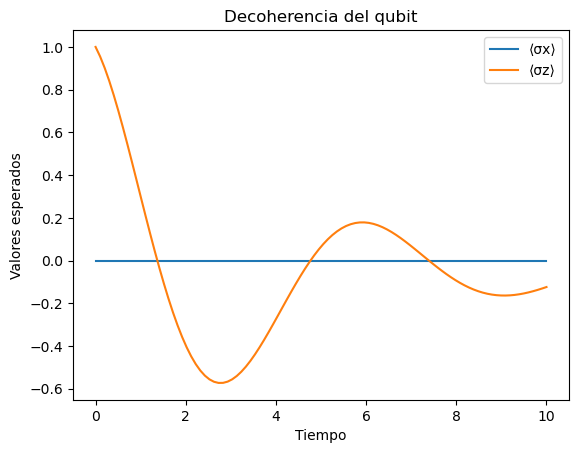

In [15]:
import matplotlib.pyplot as plt

plt.plot(tlist, result.expect[0], label="⟨σx⟩")
plt.plot(tlist, result.expect[1], label="⟨σz⟩")

plt.xlabel("Tiempo")
plt.ylabel("Valores esperados")
plt.legend()
plt.title("Decoherencia del qubit")
plt.show()